In [3]:
from mp_api.client import MPRester
import pandas as pd
API_KEY = "YOUR_API_KEY_HERE"

with MPRester(API_KEY) as mpr:
    
    docs = mpr.materials.summary.search(
        energy_above_hull=(0, 0.1),   # stable materials
        fields=[
            "material_id",
            "formula_pretty",
            "formation_energy_per_atom",
            "band_gap",
            "density",
            "energy_above_hull"
        ],
        chunk_size=200
    )

    docs = list(docs)[:5000]   # limit dataset size

data = pd.DataFrame([doc.dict() for doc in docs])

print(data.shape)

data.to_csv("materials_project_dataset.csv", index=False)

Retrieving SummaryDoc documents: 100%|████████████████████████████████████████| 103644/103644 [01:52<00:00, 921.15it/s]


(5000, 7)


In [5]:
data.head(10)

,formula_pretty,density,material_id,formation_energy_per_atom,energy_above_hull,band_gap,fields_not_requested
0,Ac,8.157868,mp-ovi,0.021639,0.021639,0.0,"[builder_meta, nsites, elements, nelements, co..."
1,Ac,8.313274,mp-cpicf,0.015586,0.015586,0.0,"[builder_meta, nsites, elements, nelements, co..."
2,Ac,8.144760,mp-cpicr,0.011822,0.011822,0.0,"[builder_meta, nsites, elements, nelements, co..."
3,Ac,8.170182,mp-bxcek,0.000000,0.000000,0.0,"[builder_meta, nsites, elements, nelements, co..."
4,Ac2AgIr,11.367264,mp-bxatg,-0.413285,0.087118,0.0,"[builder_meta, nsites, elements, nelements, co..."
5,Ac2AgPb,9.490476,mp-cpicy,-0.480278,0.000000,0.0,"[builder_meta, nsites, elements, nelements, co..."
6,Ac2CdGa,8.243210,mp-cpicq,-0.402831,0.027137,0.0,"[builder_meta, nsites, elements, nelements, co..."
7,Ac2CdGe,8.449542,mp-cpicl,-0.464809,0.059054,0.0,"[builder_meta, nsites, elements, nelements, co..."
8,Ac2CdHg,9.570977,mp-cpidi,-0.433682,0.000000,0.0,"[builder_meta, nsites, elements, nelements, co..."
9,Ac2CdSn,8.370293,mp-bxbqd,-0.542654,0.074600,0.0,"[builder_meta, nsites, elements, nelements, co..."


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [8]:
data.describe()

,density,formation_energy_per_atom,energy_above_hull,band_gap
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.566609,-1.733927,0.020546,1.549375
std,2.310447,1.131719,0.027305,1.788597
min,0.624552,-4.467987,0.000000,0.000000
25%,4.123631,-2.736659,0.000000,0.000000
50%,5.436736,-1.853717,0.006575,0.881350
75%,6.745454,-0.607039,0.034171,2.807200
max,18.889325,0.099731,0.099982,8.513200


In [9]:
data = data.drop(columns=["fields_not_requested"])
data = data.drop(columns=["material_id"])
print(data.columns)

Index(['formula_pretty', 'density', 'formation_energy_per_atom',
       'energy_above_hull', 'band_gap'],
      dtype='object')


In [10]:
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

data = StrToComposition().featurize_dataframe(data, "formula_pretty")

ep = ElementProperty.from_preset("magpie")

data = ep.featurize_dataframe(data, col_id="composition")

StrToComposition: 100%|████████████████████████████████████████████████████████████| 5000/5000 [01:46<00:00, 46.95it/s]
C:\Users\saish\AppData\Local\Programs\Python\Python313\Lib\site-packages\matminer\utils\data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)
ElementProperty: 100%|█████████████████████████████████████████████████████████████| 5000/5000 [02:12<00:00, 37.62it/s]


In [11]:
data.head()

,formula_pretty,density,formation_energy_per_atom,energy_above_hull,band_gap,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Ac,8.157868,0.021639,0.021639,0.0,(Ac),89.0,89.0,0.0,89.0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
1,Ac,8.313274,0.015586,0.015586,0.0,(Ac),89.0,89.0,0.0,89.0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
2,Ac,8.144760,0.011822,0.011822,0.0,(Ac),89.0,89.0,0.0,89.0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
3,Ac,8.170182,0.000000,0.000000,0.0,(Ac),89.0,89.0,0.0,89.0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
4,Ac2AgIr,11.367264,-0.413285,0.087118,0.0,"(Ac, Ag, Ir)",47.0,89.0,42.0,75.5,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0


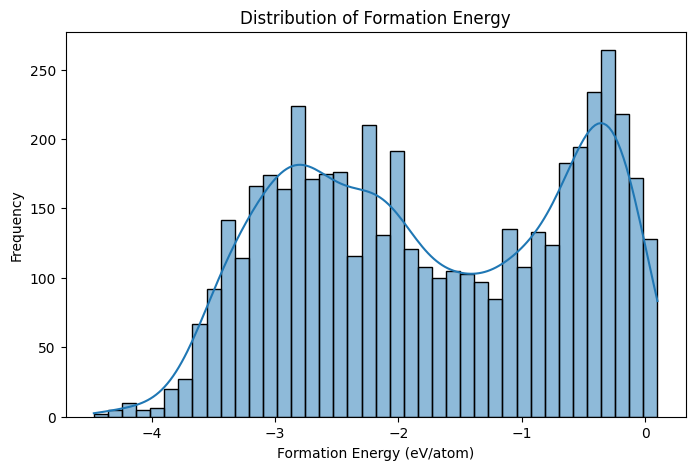

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(data["formation_energy_per_atom"], bins=40, kde=True)

plt.title("Distribution of Formation Energy")
plt.xlabel("Formation Energy (eV/atom)")
plt.ylabel("Frequency")

plt.show()

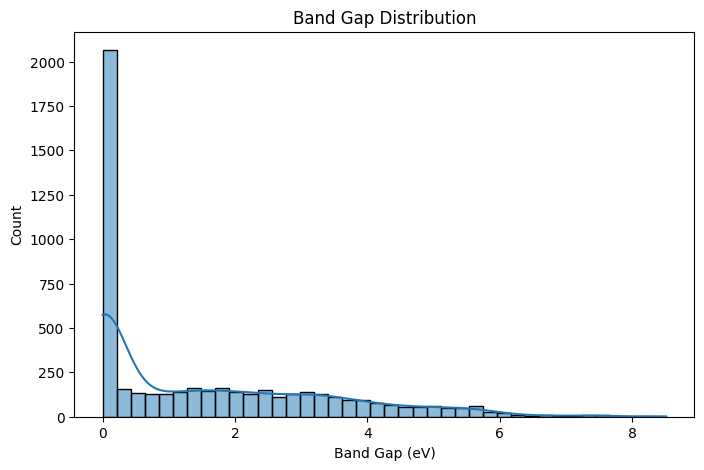

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(data["band_gap"], bins=40, kde=True)

plt.title("Band Gap Distribution")
plt.xlabel("Band Gap (eV)")

plt.show()

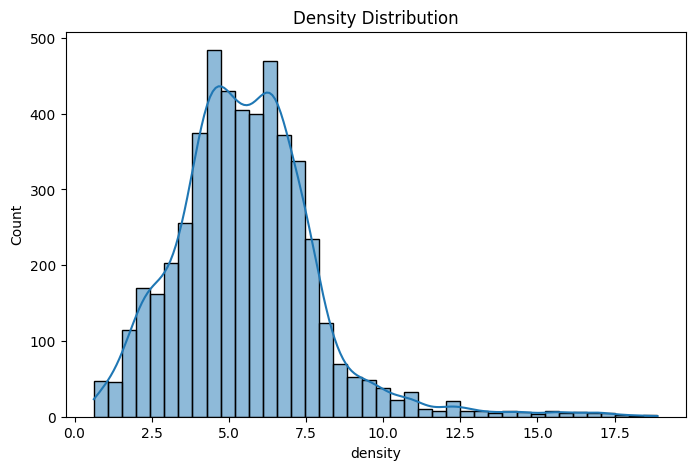

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(data["density"], bins=40, kde=True)

plt.title("Density Distribution")

plt.show()

,density,formation_energy_per_atom,energy_above_hull,band_gap,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,8.157868,0.021639,0.021639,0.0,(Ac),89.0,89.0,0.0,89.0,0.00,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
1,8.313274,0.015586,0.015586,0.0,(Ac),89.0,89.0,0.0,89.0,0.00,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
2,8.144760,0.011822,0.011822,0.0,(Ac),89.0,89.0,0.0,89.0,0.00,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
3,8.170182,0.000000,0.000000,0.0,(Ac),89.0,89.0,0.0,89.0,0.00,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0
4,11.367264,-0.413285,0.087118,0.0,"(Ac, Ag, Ir)",47.0,89.0,42.0,75.5,14.25,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.0,0.0,225.0


In [31]:
X = data.drop(
    columns=[
        "formula_pretty",
        "composition",
        "formation_energy_per_atom"
    ],
    errors="ignore"
)

y = data["formation_energy_per_atom"]

X = X.fillna(X.mean())

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=10000
)

lasso.fit(X_train_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,10000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [35]:
import numpy as np

coef = lasso.coef_

selected_features = X.columns[coef != 0]

print("Number of selected features:", len(selected_features))

print(selected_features)

Number of selected features: 77
Index(['density', 'energy_above_hull', 'band_gap', 'MagpieData range Number',
       'MagpieData avg_dev Number', 'MagpieData range MendeleevNumber',
       'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber',
       'MagpieData minimum MeltingT', 'MagpieData avg_dev MeltingT',
       'MagpieData range Column', 'MagpieData mean Column',
       'MagpieData avg_dev Column', 'MagpieData maximum Row',
       'MagpieData range Row', 'MagpieData avg_dev Row',
       'MagpieData maximum CovalentRadius', 'MagpieData mean CovalentRadius',
       'MagpieData avg_dev CovalentRadius',
       'MagpieData minimum Electronegativity',
       'MagpieData avg_dev Electronegativity',
       'MagpieData mode Electronegativity', 'MagpieData maximum NsValence',
       'MagpieData mean NsValence', 'MagpieData avg_dev NsValence',
       'MagpieData mode NsValence', 'MagpieData minimum NpValence',
       'MagpieData maximum NpValence', 'MagpieData mean NpVale

In [36]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [37]:
coef = lasso.coef_

selected_features = X.columns[coef != 0]

print(len(selected_features))

39


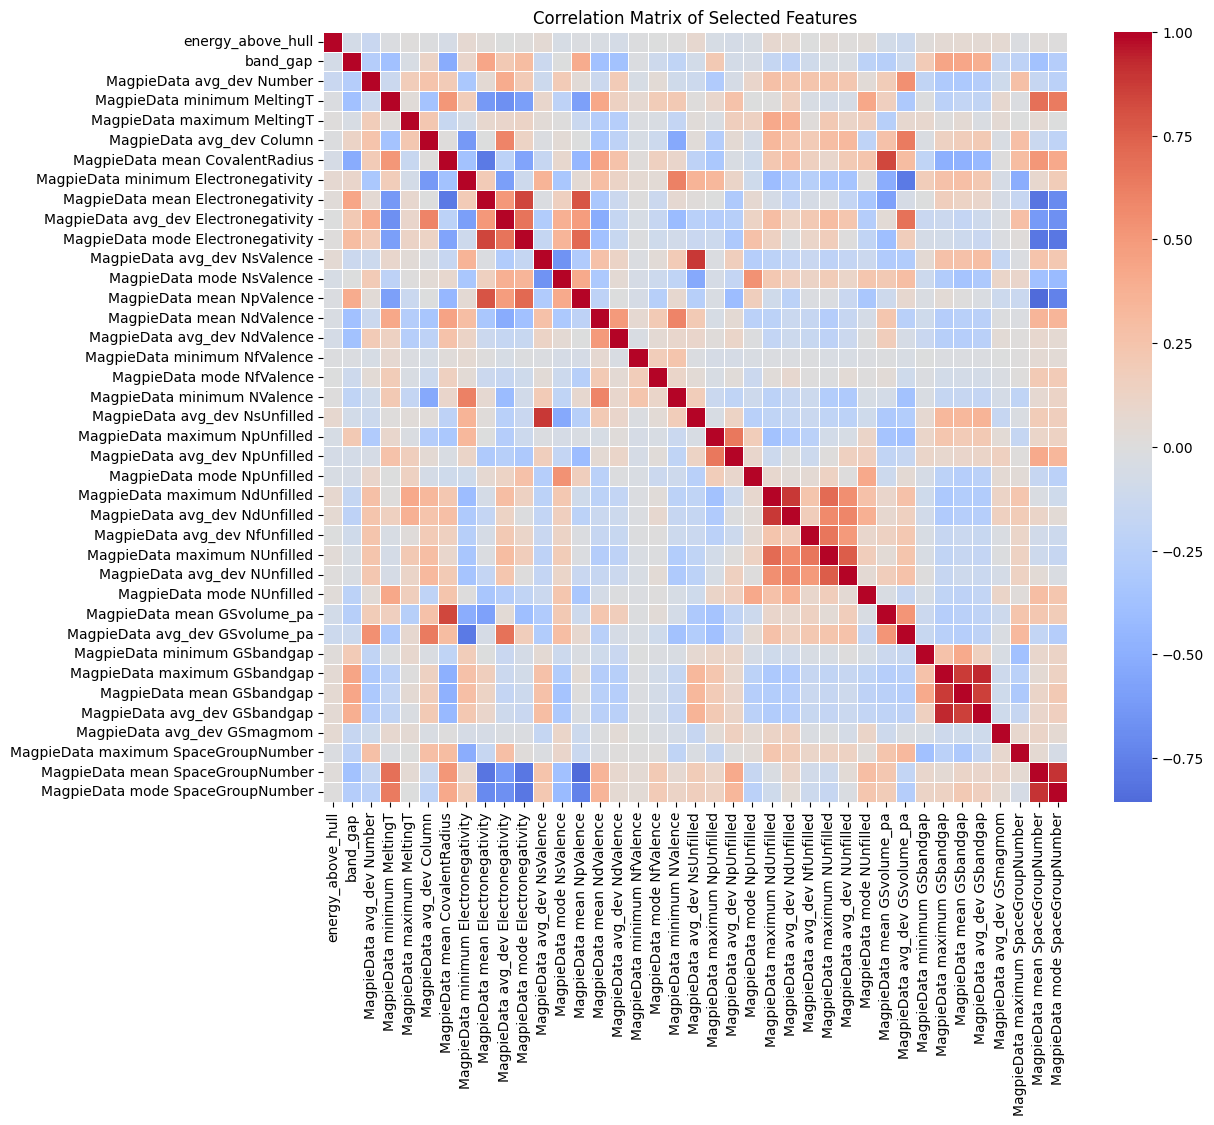

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X[selected_features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Selected Features")

plt.show()

In [39]:
corr_target = data[selected_features].corrwith(data["formation_energy_per_atom"])

corr_target = corr_target.sort_values(ascending=False)

print(corr_target)

MagpieData mode SpaceGroupNumber        0.724494
MagpieData mean SpaceGroupNumber        0.706928
MagpieData minimum MeltingT             0.599807
MagpieData mean NdValence               0.569485
MagpieData minimum Electronegativity    0.484142
MagpieData minimum NValence             0.391576
MagpieData avg_dev NsValence            0.380017
MagpieData avg_dev NsUnfilled           0.356759
MagpieData mean CovalentRadius          0.337039
MagpieData avg_dev NdValence            0.335495
MagpieData avg_dev NpUnfilled           0.233056
MagpieData mode NUnfilled               0.213606
MagpieData mean GSbandgap               0.204538
MagpieData avg_dev GSbandgap            0.166752
MagpieData mode NfValence               0.164387
MagpieData maximum GSbandgap            0.151636
MagpieData minimum GSbandgap            0.137662
MagpieData maximum NpUnfilled           0.130675
MagpieData mean GSvolume_pa             0.116474
MagpieData minimum NfValence            0.037717
MagpieData avg_dev G

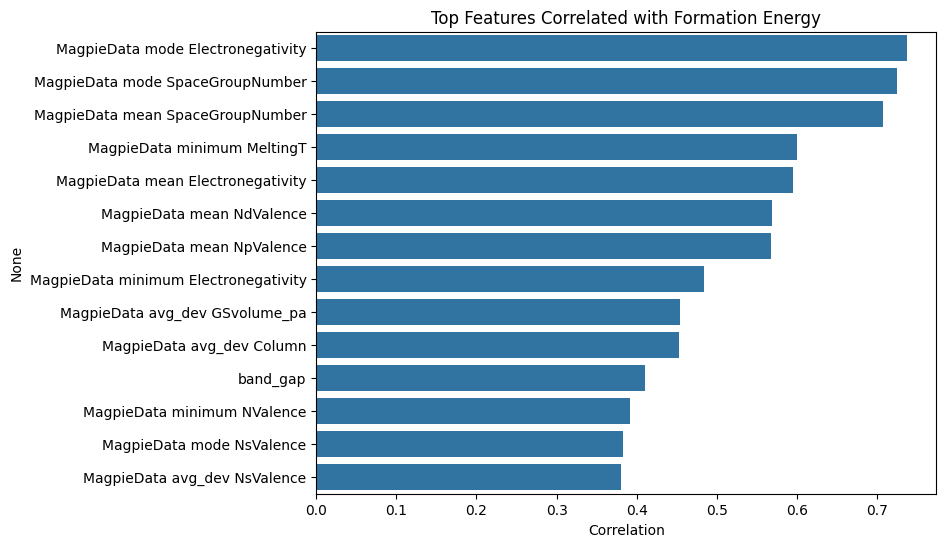

In [40]:
top_corr = corr_target.abs().sort_values(ascending=False)[1:15]

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Formation Energy")

plt.xlabel("Correlation")

plt.show()

In [50]:
X = X.drop(columns=["band_gap"], errors="ignore")
selected_features = [f for f in selected_features if f in X.columns]

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[selected_features])

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

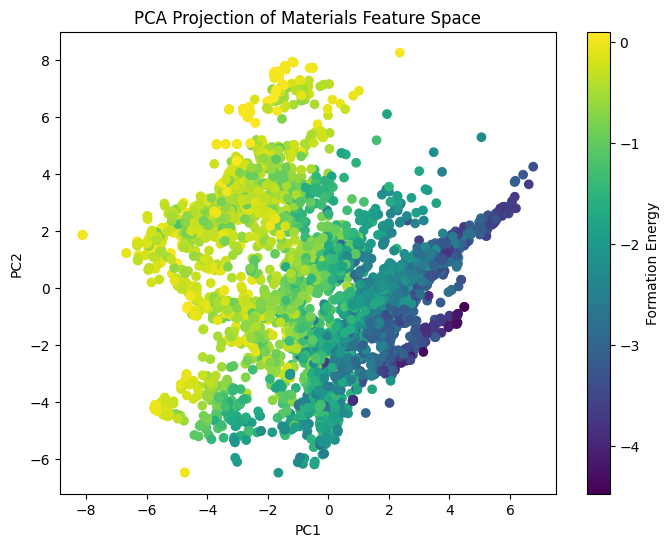

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis")

plt.colorbar(label="Formation Energy")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Projection of Materials Feature Space")

plt.show()

In [54]:
X_selected = X[selected_features]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = rf_model.predict(X_test)

In [58]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("MAE:", mae)

R² Score: 0.9841049692475835
MAE: 0.08804304517840146


In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X_selected,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R²:", scores.mean())

Cross-Validation R²: 0.9603063036808722


In [60]:
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9981131526019832
Test R2: 0.9841049692475835


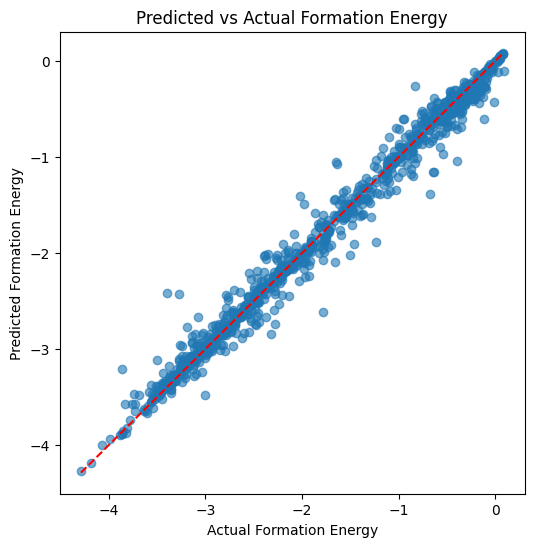

In [61]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Formation Energy")
plt.ylabel("Predicted Formation Energy")

plt.title("Predicted vs Actual Formation Energy")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [1]:
import os
print(os.getcwd())

C:\Users\saish
